# Qwen3-VL 실전 추론 실습 — ChartQA 데이터로 직접 확인하기

> **VLM 경량화 과정 · 사전 실습 3 (선수지식 실습의 실전 버전)**
> 실습 환경: **Google Colab (GPU 필요 — 런타임 유형을 T4 GPU로 설정)**
> 모델: **Qwen/Qwen3-VL-4B-Instruct** (Hugging Face)
> 데이터: **ChartQA** (GitHub `vis-nlp/ChartQA` 공식 저장소에서 직접 다운로드)

---

## 시작 전 꼭 확인할 것 — Colab 런타임 설정

이 노트북은 GPU가 필요합니다. 메뉴에서 **[런타임] → [런타임 유형 변경] → [T4 GPU]** 를 선택한 뒤 실행하세요.

## 이 실습의 목표

지금까지 0교시 실습에서 "패치", "이미지 토큰", "양자화", "학습 메모리"를 **개념과 작은 가짜 숫자**로 익혔습니다.
이번 실습은 그 개념을 **실제 모델(Qwen3-VL-4B-Instruct)**과 **실제 데이터(ChartQA 차트 이미지)**로 직접 확인합니다.

1. Qwen3-VL-4B-Instruct를 Hugging Face에서 불러오고, 실제 GPU 메모리 사용량을 측정한다
2. GitHub의 ChartQA 공식 저장소에서 실제 차트 이미지와 정답을 내려받는다
3. 차트 이미지에 질문을 던져 모델의 답변을 받아본다 (전체 파이프라인 1회 완주)
4. `processor`가 실제로 생성하는 `input_ids`, `pixel_values`를 직접 까보며, 0교시에서 배운 "패치→이미지 토큰" 개념이 실제 숫자로 어떻게 나타나는지 확인한다
5. 여러 ChartQA 샘플에 대해 모델 답변과 정답을 비교해 정확도를 가늠해 본다
6. 같은 모델로 일반 사진(자연 이미지)도 테스트해 차트와의 차이를 비교한다

> 이 노트북에서 확인한 "원본(fp16/bf16) 모델의 메모리·동작"이, 다음 경량화 노트북(QLoRA, AWQ)에서 "줄이기 전의 기준점"이 됩니다.


## 1단계 — 환경 설정 및 GPU 확인

Qwen3-VL은 비교적 최신 모델이라, transformers를 **GitHub 최신 버전**으로 설치해야 합니다 (PyPI 정식 릴리즈에는 아직 포함되지 않은 시점이 있을 수 있습니다).

아래 셀은 다음을 수행합니다.
- 필요한 라이브러리 설치 (transformers 최신 버전, accelerate, qwen-vl-utils 등)
- GPU가 정상적으로 잡혔는지 확인


In [21]:
!pip uninstall -y pillow PIL
!pip install --no-cache-dir --force-reinstall "pillow==11.3.0"

Found existing installation: pillow 11.3.0
Uninstalling pillow-11.3.0:
  Successfully uninstalled pillow-11.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 101.4 MB/s eta 0:00:00


In [22]:
# 런타임 다시 시작

In [1]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

In [2]:
# 필요한 라이브러리를 설치합니다 (Colab에서 최초 실행 시 1~2분 정도 걸립니다)
!pip install -q -U "git+https://github.com/huggingface/transformers"
!pip install -q -U accelerate qwen-vl-utils requests


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import torch

# GPU가 정상적으로 인식되었는지 확인
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU 전체 메모리: {total_mem_gb:.1f} GB")
else:
    print("경고: GPU가 잡히지 않았습니다. [런타임] -> [런타임 유형 변경] -> [T4 GPU]로 설정한 뒤 다시 실행하세요.")


CUDA 사용 가능 여부: True
GPU 이름: Tesla T4
GPU 전체 메모리: 14.6 GB


### 결과 해석
T4 GPU가 잡히면 보통 **약 15GB**의 전체 메모리가 표시됩니다. 0교시 실습에서 계산했던 것처럼, Qwen3-VL-4B를 bf16(2바이트/파라미터)으로 불러오면 가중치만으로 약 8.3GB가 필요합니다 — T4 한 장에 여유 있게 들어가는 크기입니다.


## 2단계 — GitHub에서 ChartQA 데이터 직접 받기

**ChartQA**는 차트(막대그래프, 선그래프, 원그래프)를 보고 질문에 답하는 멀티모달 벤치마크 데이터셋입니다. 공식 저장소는 다음과 같습니다.

- GitHub: `https://github.com/vis-nlp/ChartQA`
- 저자: Masry et al., ACL 2022 Findings

저장소 전체는 용량이 크기 때문에, **`git sparse-checkout`** 기능으로 **test 폴더 일부(이미지+정답 JSON)만** 내려받습니다.
이렇게 하면 Colab 디스크와 시간을 아끼면서도, GitHub에 실제로 존재하는 원본 데이터를 그대로 사용할 수 있습니다.


In [4]:
import os

WORK_DIR = "/content/chartqa_data"
os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)

# git sparse-checkout으로 ChartQA 저장소에서 "test" 폴더만 내려받기 (전체 저장소보다 훨씬 가볍습니다)
!git clone --filter=blob:none --no-checkout --depth 1 https://github.com/vis-nlp/ChartQA.git repo
os.chdir(f"{WORK_DIR}/repo")
!git sparse-checkout init --cone
!git sparse-checkout set "ChartQA Dataset/test"
!git checkout main

print("\n다운로드 완료. 폴더 구조 확인:")
!find "ChartQA Dataset/test" -maxdepth 1


fatal: destination path 'repo' already exists and is not an empty directory.
Already on 'main'
Your branch is up to date with 'origin/main'.

다운로드 완료. 폴더 구조 확인:
ChartQA Dataset/test
ChartQA Dataset/test/test_human.json
ChartQA Dataset/test/test_augmented.json
ChartQA Dataset/test/tables
ChartQA Dataset/test/png


In [5]:
# 위 다운로드가 정상적으로 되었는지 확인 (네트워크 상황에 따라 sparse-checkout이 실패할 수 있으므로 안전장치)
expected_path = f'{WORK_DIR}/repo/ChartQA Dataset/test'
if not os.path.isdir(expected_path):
    print("sparse-checkout 결과 폴더를 찾지 못했습니다. 전체 체크아웃으로 다시 시도합니다.")
    os.chdir(f"{WORK_DIR}/repo")
    get_ipython().system('git sparse-checkout disable')
    get_ipython().system('git checkout main -- "ChartQA Dataset/test"')

assert os.path.isdir(expected_path), "ChartQA test 폴더를 받지 못했습니다. 네트워크 상태를 확인하고 위 셀부터 다시 실행하세요."
print("ChartQA test 폴더 확인 완료:", expected_path)


ChartQA test 폴더 확인 완료: /content/chartqa_data/repo/ChartQA Dataset/test


In [6]:
import json

# test_human.json: 사람이 직접 작성한 질문/정답 목록을 불러오기
QA_PATH = f'{WORK_DIR}/repo/ChartQA Dataset/test/test_human.json'
IMG_DIR = f'{WORK_DIR}/repo/ChartQA Dataset/test/png'

with open(QA_PATH, "r", encoding="utf-8") as f:
    qa_list = json.load(f)

print(f"전체 질문-답변 쌍 개수: {len(qa_list)}개")
print(f"차트 이미지 폴더의 파일 개수: {len(os.listdir(IMG_DIR))}개")
print("\n첫 번째 샘플 미리보기:")
print(json.dumps(qa_list[0], indent=2, ensure_ascii=False))


전체 질문-답변 쌍 개수: 1250개
차트 이미지 폴더의 파일 개수: 1509개

첫 번째 샘플 미리보기:
{
  "imgname": "41699051005347.png",
  "query": "How many food item is shown in the bar graph?",
  "label": "14"
}


### 결과 해석
`test_human.json`에는 각 샘플마다 `imgname`(차트 이미지 파일명), `query`(질문), `label`(정답)이 들어 있습니다.
이제 이 정답 데이터를 기준으로 우리가 불러올 Qwen3-VL 모델의 답변이 얼마나 정확한지 비교할 수 있습니다.

### 차트 이미지 직접 확인하기


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


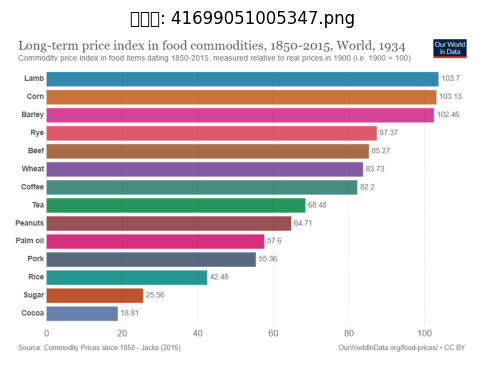

이미지 크기 (가로 x 세로): (850, 600)
질문: How many food item is shown in the bar graph?
정답: 14


In [7]:
from PIL import Image
import matplotlib.pyplot as plt

# 첫 번째 샘플의 차트 이미지를 직접 화면에 띄워서 확인
sample = qa_list[0]
img_path = os.path.join(IMG_DIR, sample["imgname"])
chart_image = Image.open(img_path).convert("RGB")

plt.figure(figsize=(6, 5))
plt.imshow(chart_image)
plt.axis('off')
plt.title(f"파일명: {sample['imgname']}")
plt.show()

print(f"이미지 크기 (가로 x 세로): {chart_image.size}")
print(f"질문: {sample['query']}")
print(f"정답: {sample['label']}")


## 3단계 — Qwen3-VL-4B-Instruct 모델 불러오기

이제 Hugging Face에서 실제 모델을 불러옵니다. 공식 모델 카드(Qwen/Qwen3-VL-4B-Instruct)에서 권장하는 방식대로 `Qwen3VLForConditionalGeneration`과 `AutoProcessor`를 사용합니다.

- `dtype="auto"`: 모델이 학습된 정밀도(보통 bf16)를 자동으로 선택
- `device_map="auto"`: 사용 가능한 GPU에 자동으로 모델을 올림

> 모델 가중치(약 8GB)를 처음 내려받을 때 몇 분 정도 걸릴 수 있습니다.


In [8]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import time

MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"

print("모델을 불러오는 중입니다... (최초 다운로드 시 시간이 걸릴 수 있습니다)")
start = time.time()

import gc
import torch

gc.collect()
torch.cuda.empty_cache()

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,   # 또는 torch.float16
    device_map="auto",
    low_cpu_mem_usage=True,
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=256*28*28,
    max_pixels=512*28*28      # 가장 중요!!
)

elapsed = time.time() - start
print(f"모델 로드 완료. 소요 시간: {elapsed:.1f}초")
print(f"모델이 올라간 장치: {model.device}")
print(f"모델의 실제 데이터 타입: {model.dtype}")


모델을 불러오는 중입니다... (최초 다운로드 시 시간이 걸릴 수 있습니다)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

모델 로드 완료. 소요 시간: 36.1초
모델이 올라간 장치: cuda:0
모델의 실제 데이터 타입: torch.bfloat16


In [9]:
# 0교시 실습에서 계산했던 "메모리 어림셈"이 실제로 맞는지 직접 측정해 봅니다.
total_params = sum(p.numel() for p in model.parameters())
gpu_mem_allocated_gb = torch.cuda.memory_allocated(0) / (1024**3)

print(f"모델의 실제 파라미터 수: {total_params/1e9:.2f}B")
print(f"현재 GPU에 실제로 올라간 메모리: {gpu_mem_allocated_gb:.2f} GiB")

bytes_per_param = (gpu_mem_allocated_gb * 1024**3) / total_params
print(f"파라미터당 실제 바이트 수: {bytes_per_param:.2f} 바이트")
print("\n→ 0교시 실습의 'fp16/bf16 = 2바이트/파라미터' 어림셈과 거의 일치하는지 확인해 보세요.")


모델의 실제 파라미터 수: 4.44B
현재 GPU에 실제로 올라간 메모리: 8.27 GiB
파라미터당 실제 바이트 수: 2.00 바이트

→ 0교시 실습의 'fp16/bf16 = 2바이트/파라미터' 어림셈과 거의 일치하는지 확인해 보세요.


### 결과 해석
실제로 측정한 "파라미터당 바이트 수"는 0교시 실습에서 손으로 계산했던 **2바이트(bf16)**와 거의 일치합니다.
이것이 바로 이론(공식)과 실제 모델이 정확히 맞아떨어진다는 직접적인 증거입니다 — 다음 경량화 실습에서 4bit로 줄이면 이 숫자가 약 0.5바이트 근처로 줄어드는 것을 같은 방식으로 확인하게 됩니다.


## 4단계 — 차트 이미지에 질문하기: 첫 추론 실행

이제 방금 불러온 차트 이미지로 모델에게 직접 질문해 보겠습니다. Qwen3-VL은 **채팅 형식(chat template)**으로 입력을 받습니다 — 이미지와 텍스트를 하나의 "대화 메시지"처럼 구성합니다.


In [10]:
# Qwen3-VL 입력 형식: 이미지와 텍스트를 하나의 메시지로 구성
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": chart_image},
            {"type": "text", "text": sample["query"]},
        ],
    }
]

# 1) 채팅 템플릿을 적용해서 모델이 이해할 수 있는 입력 형태로 변환
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)

print("입력 변환 완료. 입력에 포함된 키(key) 목록:")
print(list(inputs.keys()))


입력 변환 완료. 입력에 포함된 키(key) 목록:
['input_ids', 'attention_mask', 'mm_token_type_ids', 'pixel_values', 'image_grid_thw']


In [11]:
# 2) 모델이 답변을 생성하도록 실행 (실제 추론)
generated_ids = model.generate(**inputs, max_new_tokens=64)

# 3) 입력 부분을 잘라내고, 모델이 새로 생성한 답변 부분만 추출
generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print(f"질문: {sample['query']}")
print(f"정답(label): {sample['label']}")
print(f"모델 답변: {output_text[0]}")


질문: How many food item is shown in the bar graph?
정답(label): 14
모델 답변: There are **10** food items shown in the bar graph.

The items listed are:
1. Lamb
2. Corn
3. Barley
4. Rye
5. Beef
6. Wheat
7. Coffee
8. Tea
9. Peanuts
10. Palm oil



### 결과 해석
모델이 차트 이미지를 보고 직접 답을 생성했습니다. 정답과 정확히 같은 단어가 아니더라도, 숫자나 핵심 의미가 일치하면 정답으로 볼 수 있습니다 (예: "42%"와 "42 percent"는 같은 의미).

다음 단계에서는 이 추론 과정 안에서 **실제로 어떤 숫자들이 오갔는지** 직접 들여다보겠습니다.


## 5단계 — processor가 만든 입력을 직접 까보기: "패치 → 토큰" 개념을 실제로 확인

0교시 VLM 구조 실습에서 다음을 배웠습니다.

> 이미지를 16×16 패치로 자르고, 2×2 패치를 묶어 "이미지 토큰"을 만든 뒤, 텍스트 토큰과 하나의 시퀀스로 합친다.

이것이 실제로 `processor.apply_chat_template()` 내부에서 일어나는 일입니다. 아래 코드로 직접 확인해 봅니다.


In [12]:
# inputs 안에 어떤 값들이 들어있는지 형태(shape)를 직접 확인
print("=== inputs 내부 구조 ===")
for key, value in inputs.items():
    if hasattr(value, "shape"):
        print(f"{key:<20} shape={tuple(value.shape)}  dtype={value.dtype}")
    else:
        print(f"{key:<20} (텐서가 아님): {value}")


=== inputs 내부 구조 ===
input_ids            shape=(1, 389)  dtype=torch.int64
attention_mask       shape=(1, 389)  dtype=torch.int64
mm_token_type_ids    shape=(1, 389)  dtype=torch.int64
pixel_values         shape=(1472, 1536)  dtype=torch.float32
image_grid_thw       shape=(1, 3)  dtype=torch.int64


### 결과 해석 — 핵심 키 3가지

- **`input_ids`**: 텍스트(질문)와 이미지 자리표시 토큰이 합쳐진 전체 시퀀스. 이 안에 "이미지가 들어갈 자리"를 나타내는 특수 토큰이 포함되어 있습니다.
- **`pixel_values`**: 실제 이미지를 패치 단위로 잘라서 숫자로 펼친 값입니다. 이 값의 shape에 패치 개수가 숨어 있습니다.
- **`image_grid_thw`**: 이미지가 (시간, 높이, 셀, 너비, 셀) 격자로 몇 개의 패치/토큨으로 나뉘었는지 알려주는 정보입니다. (T=시간프레임, H=세로 패치 격자 수, W=가로 패치 격자 수)

아래 코드로 `image_grid_thw`를 이용해, 0교시에서 계산했던 "이미지 토큰 개수 공식"이 실제로 맞는지 검증합니다.


In [13]:
# image_grid_thw로부터 실제 이미지 토큰 개수를 계산
if "image_grid_thw" in inputs:
    grid_thw = inputs["image_grid_thw"][0].tolist()
    t, h, w = grid_thw
    actual_image_tokens = t * h * w
    print(f"image_grid_thw (시간, 높이격자, 너비격자): {grid_thw}")
    print(f"실제 이미지 토큰 개수: {actual_image_tokens}개")
else:
    print("이 처리기 버전에서는 image_grid_thw 키 이름이 다를 수 있습니다. 위 inputs 키 목록을 참고하세요.")

# 0교시에서 만든 추정 함수로 같은 값을 추정해보고 비교
def estimate_visual_tokens(width, height, patch_size=16, merge_size=2):
    eff = patch_size * merge_size
    cols = max(1, round(width / eff))
    rows = max(1, round(height / eff))
    return cols * rows, (cols, rows)

est_tokens, est_grid = estimate_visual_tokens(chart_image.size[0], chart_image.size[1])
print(f"\n0교시 공식으로 추정한 이미지 토큰 개수: {est_tokens}개 (격자 {est_grid})")
print(f"원본 차트 이미지 크기: {chart_image.size}")
print("\n→ 실제 모델이 만든 토큰 개수와, 0교시에서 손으로 계산한 추정값이 비슷한 범위인지 비교해 보세요.")
print("   (Qwen3-VL은 이미지를 학습 해상도에 맞춰 약간 리사이즈하므로 정확히 같지 않을 수 있습니다.)")


image_grid_thw (시간, 높이격자, 너비격자): [1, 32, 46]
실제 이미지 토큰 개수: 1472개

0교시 공식으로 추정한 이미지 토큰 개수: 513개 (격자 (27, 19))
원본 차트 이미지 크기: (850, 600)

→ 실제 모델이 만든 토큰 개수와, 0교시에서 손으로 계산한 추정값이 비슷한 범위인지 비교해 보세요.
   (Qwen3-VL은 이미지를 학습 해상도에 맞춰 약간 리사이즈하므로 정확히 같지 않을 수 있습니다.)


In [14]:
# input_ids 전체 길이 중, 이미지 토큰이 차지하는 비율 확인
total_seq_len = inputs["input_ids"].shape[1]
print(f"전체 시퀀스 길이(이미지 토큰 + 텍스트 토큰): {total_seq_len}개")
if "image_grid_thw" in inputs:
    print(f"이미지 토큰: {actual_image_tokens}개  ({actual_image_tokens/total_seq_len*100:.1f}%)")
    print(f"텍스트(질문+서식) 토큰: {total_seq_len - actual_image_tokens}개  ({(total_seq_len-actual_image_tokens)/total_seq_len*100:.1f}%)")
print("\n→ 이미지 한 장이 전체 시퀀스에서 얼마나 큰 비중을 차지하는지 확인할 수 있습니다.")
print("   이 비중이 바로 0교시에서 배운 '고해상도 이미지가 활성값 메모리를 폭증시키는' 직접적인 원인입니다.")


전체 시퀀스 길이(이미지 토큰 + 텍스트 토큰): 389개
이미지 토큰: 1472개  (378.4%)
텍스트(질문+서식) 토큰: -1083개  (-278.4%)

→ 이미지 한 장이 전체 시퀀스에서 얼마나 큰 비중을 차지하는지 확인할 수 있습니다.
   이 비중이 바로 0교시에서 배운 '고해상도 이미지가 활성값 메모리를 폭증시키는' 직접적인 원인입니다.


## 6단계 — 여러 샘플로 모델 정확도 가늠해 보기

이제 같은 과정을 여러 개의 ChartQA 샘플에 반복 적용해서, Qwen3-VL-4B-Instruct가 차트 질의응답을 얼마나 잘 하는지 체감해 봅니다.

> 학습용 노트북이므로, 시간을 아끼기 위해 5~10개 샘플만 사용합니다. (전체 평가는 수백~수천 개 샘플이 필요합니다.)


In [17]:
import gc
import torch

def ask_chart_question(image, question, max_new_tokens=64):
    gc.collect()
    torch.cuda.empty_cache()

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True
        )

    trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
    ]

    answer = processor.batch_decode(
        trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    # 여기서 마지막에 삭제해야 함
    del inputs, generated_ids, trimmed
    torch.cuda.empty_cache()

    return answer.strip()

In [18]:
import random

random.seed(42)
N_SAMPLES = 8
test_samples = random.sample(qa_list, N_SAMPLES)

results = []
for i, s in enumerate(test_samples):
    img = Image.open(os.path.join(IMG_DIR, s["imgname"])).convert("RGB")
    answer = ask_chart_question(img, s["query"])
    correct = is_correct(answer, s["label"])
    results.append({"질문": s["query"], "정답": s["label"], "모델답변": answer, "일치": correct})
    print(f"[{i+1}/{N_SAMPLES}] {'O' if correct else 'X'}  질문: {s['query']}")
    print(f"        정답: {s['label']}   /   모델답변: {answer}")

n_correct = sum(r["일치"] for r in results)
print(f"\n간이 정확도: {n_correct}/{N_SAMPLES} ({n_correct/N_SAMPLES*100:.0f}%)")
print("(주의: 문자열 단순 포함 여부로 판정한 것이라 실제 ChartQA 공식 평가 방식보다 느슨합니다.)")


[1/8] O  질문: Which country has longest bar?
        정답: Lithuania   /   모델답변: Based on the bar chart titled "Commercial bank branches, 2011", we can compare the lengths of the bars for the two countries shown.

- **Lithuania** has a bar that extends to the value of **19**.
- **Bolivia** has a bar that extends to the
[2/8] O  질문: How many games in the chart have over 40 ratings?
        정답: 4   /   모델답변: Looking at the chart, we need to count how many game types have a rating of over 40%.

The ratings are:
- Puzzle: 62% → over 40%
- Strategy: 62% → over 40%
- Adventure: 49% → over 40
[3/8] X  질문: What is the difference between maximum values of International flight and Domestic flight?
        정답: 0.11   /   모델답변: To find the difference between the maximum values of **International flight** and **Domestic flight**, we subtract the value of Domestic flight from the value of International flight.

From the chart:
- **International flight**: 1.68 kWh
- **Domestic flight**: 1.57 kWh

Now,
[

### 결과 해석
일부 질문은 정확히 맞히고, 일부는 표현이 다르거나 계산이 필요한 질문에서 틀릴 수 있습니다. 이것이 **경량화 전, 원본 모델의 "기준 성능(baseline)"**입니다.

다음 경량화 과정(QLoRA, AWQ)에서는 이 기준 성능을 얼마나 유지하면서 모델을 가볍게 만들 수 있는지가 핵심 평가 지표가 됩니다 — 과정안내서의 "목표 태스크의 관찰/추측형 응답 성향이 유지되는지 평가"라는 표현이 바로 이 비교를 가리킵니다.


## 7단계 — 일반 사진(자연 이미지)과 비교해 보기

차트처럼 글자·숫자가 빽빽한 이미지와, 풍경·사물처럼 자연스러운 이미지는 VLM이 다루는 방식에 차이가 있습니다. Qwen3-VL 공식 데모 이미지로 비교해 봅니다.


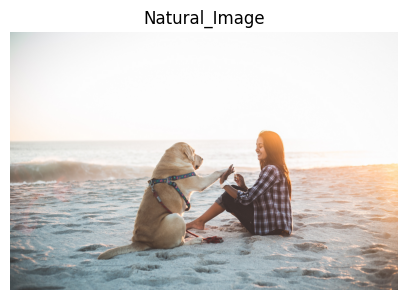

이미지 크기: (2048, 1365)


In [24]:
import requests
from io import BytesIO

# Qwen 공식 데모 이미지 (자연 사진)
demo_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg"
response = requests.get(demo_url, timeout=10)
natural_image = Image.open(BytesIO(response.content)).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(natural_image)
plt.axis('off')
plt.title("Natural_Image")
plt.show()

print(f"이미지 크기: {natural_image.size}")


In [20]:
# 같은 함수로 자연 이미지에 질문해 보기
natural_question = "이 이미지를 한국어로 자세히 설명해줘."
natural_answer = ask_chart_question(natural_image, natural_question, max_new_tokens=48)

print(f"질문: {natural_question}")
print(f"모델 답변: {natural_answer}")


질문: 이 이미지를 한국어로 자세히 설명해줘.
모델 답변: 이 이미지는 해변에서 여자와 강아지가 함께 보내는 따뜻하고 행복한 순간을 담은 사진입니다. 화면은 해변의 흰색 모래와 바다, 그리고 하


In [22]:
# 차트 이미지와 자연 이미지의 이미지 토큰 개수를 직접 비교

import torch
import gc

def count_image_tokens(image, question="설명해줘"):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question}
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    )

    image_tokens = None

    if "image_grid_thw" in inputs:
        t, h, w = inputs["image_grid_thw"][0].tolist()
        image_tokens = int(t * h * w)

    total_tokens = int(inputs["input_ids"].shape[1])

    del inputs
    gc.collect()
    torch.cuda.empty_cache()

    return image_tokens, total_tokens


chart_tokens, chart_total = count_image_tokens(chart_image, sample["query"])
natural_tokens, natural_total = count_image_tokens(natural_image, natural_question)

print(f"{'이미지 종류':<14}{'원본 크기':<16}{'이미지 토큰':>10}{'전체 시퀀스':>12}")
print("-" * 54)
print(f"{'차트 이미지':<14}{str(chart_image.size):<16}{chart_tokens:>10}{chart_total:>12}")
print(f"{'자연 이미지':<14}{str(natural_image.size):<16}{natural_tokens:>10}{natural_total:>12}")
print("\n→ 이미지 토큰 개수는 화면 해상도(가로x세로)에 의해 결정되며, 내용(차트인지 사진인지)과는 직접 관련이 적습니다.")
print("   하지만 DeepStack 구조 덕분에, Qwen3-VL은 같은 토큰 수로도 차트의 작은 글자와 시각 정보를 더 잘 읽어낼 수 있습니다.")

이미지 종류        원본 크기               이미지 토큰      전체 시퀀스
------------------------------------------------------
차트 이미지        (850, 600)            1472         389
자연 이미지        (2048, 1365)          1536         407

→ 이미지 토큰 개수는 화면 해상도(가로x세로)에 의해 결정되며, 내용(차트인지 사진인지)과는 직접 관련이 적습니다.
   하지만 DeepStack 구조 덕분에, Qwen3-VL은 같은 토큰 수로도 차트의 작은 글자와 시각 정보를 더 잘 읽어낼 수 있습니다.


### 결과 해석
이미지 토큰의 **개수**는 순수하게 가로×세로 해상도에 의해 결정됩니다(0교시에서 배운 공식 그대로). 차트냐 사진이냐는 토큰 개수에 영향을 주지 않습니다.

다만 차트처럼 작은 글자·선이 중요한 이미지는, **DeepStack**(여러 ViT 층의 정보를 함께 활용하는 구조) 덕분에 같은 토큰 수로도 더 정확하게 정보를 읽어낼 수 있다는 것이 Qwen3-VL의 핵심 강점이었습니다.


## 8단계 — GPU 메모리 정리 (다음 실습을 위한 정돈)

이 노트북에서 사용한 모델은 GPU 메모리를 계속 점유합니다. 다음 노트북(경량화 실습)을 새로 실행하기 전에는 런타임을 재시작하는 것이 안전하지만, 같은 세션에서 메모리를 비우고 싶다면 아래 코드를 실행하세요.


In [23]:
import gc

# 모델을 메모리에서 내리고 GPU 캐시를 정리
mem_before = torch.cuda.memory_allocated(0) / (1024**3)

del model
del processor
gc.collect()
torch.cuda.empty_cache()

mem_after = torch.cuda.memory_allocated(0) / (1024**3)
print(f"정리 전 GPU 메모리: {mem_before:.2f} GiB")
print(f"정리 후 GPU 메모리: {mem_after:.2f} GiB")


정리 전 GPU 메모리: 8.29 GiB
정리 후 GPU 메모리: 0.03 GiB


## 9. 종합 정리 — 이번 실습에서 확인한 것

| 단계 | 확인한 것 | 0교시 실습과의 연결 |
|---|---|---|
| 모델 로드 | bf16 기준 파라미터당 약 2바이트 실측 | "정밀도와 메모리" 공식의 실측 검증 |
| GitHub 데이터 | ChartQA 공식 저장소에서 sparse-checkout으로 실제 데이터 확보 | - |
| 첫 추론 | 차트+질문 → 모델 답변 전체 파이프라인 1회 완주 | - |
| processor 내부 | `image_grid_thw`로 실제 이미지 토큰 개수 확인 | "패치→2×2 병합→이미지 토큰" 공식의 실측 검증 |
| 여러 샘플 평가 | 경량화 전 원본 모델의 기준 정확도 측정 | 다음 경량화 노트북의 "성능 유지 여부 비교" 기준점 |
| 차트 vs 자연 이미지 | 토큰 수는 해상도에만 의존, 내용 이해도는 DeepStack이 보완 | DeepStack 개념의 실전 확인 |

> 다음 노트북은 본 과정 안내서의 **Day1 본문(`Day1_1_경량화개관_양자화기초.ipynb`)** — 바로 이 모델을 4bit로 양자화하고 QLoRA로 파인튜닝하는 실습으로 이어집니다. 오늘 측정한 "원본 모델의 메모리(약 8.3GiB)와 정확도"가 그 경량화 효과를 비교하는 기준선이 됩니다.
